# Análisis de Datos Estelares y Modelado Predictivo

Aqui se realiza un análisis exploratorio de datos estelares y se desarrolla modelos predictivos para diversas características de las estrellas, como la distancia, el índice de color, la luminosidad y la magnitud, usando Regresión Polinomial y Random Forest para comparar su rendimiento.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler

#Base de datos de estrellas como distancia, posicion, magnitud, etc
url = 'hygdata_v42.csv'
df = pd.read_csv(url, on_bad_lines='skip')
df

,id,hip,hd,hr,gl,bf,proper,ra,dec,dist,...,bayer,flam,con,comp,comp_primary,base,lum,var,var_min,var_max
0,0,NaN,NaN,NaN,NaN,NaN,Sol,0.000000,0.000000,0.0000,...,NaN,NaN,NaN,1,0,NaN,1.000000e+00,NaN,NaN,NaN
1,1,1.0,224700.0,NaN,NaN,NaN,NaN,0.000060,1.089009,219.7802,...,NaN,NaN,Psc,1,1,NaN,9.638290e+00,NaN,NaN,NaN
2,2,2.0,224690.0,NaN,NaN,NaN,NaN,0.000283,-19.498840,47.9616,...,NaN,NaN,Cet,1,2,NaN,3.922835e-01,NaN,NaN,NaN
3,3,3.0,224699.0,NaN,NaN,NaN,NaN,0.000335,38.859279,442.4779,...,NaN,NaN,And,1,3,NaN,3.869011e+02,NaN,NaN,NaN
4,4,4.0,224707.0,NaN,NaN,NaN,NaN,0.000569,-51.893546,134.2282,...,NaN,NaN,Phe,1,4,NaN,9.366989e+00,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119621,119626,NaN,124953.0,5343.0,NaN,NaN,NaN,14.267833,18.911944,100000.0000,...,NaN,NaN,Boo,1,119626,NaN,3.531832e+07,CN,6.01,5.98
119622,119627,NaN,152249.0,6263.0,NaN,NaN,NaN,16.903278,-41.850278,100000.0000,...,NaN,NaN,Sco,1,119627,NaN,2.290868e+07,NaN,NaN,NaN
119623,119628,NaN,162678.0,6660.0,NaN,NaN,NaN,17.895972,-34.786111,100000.0000,...,NaN,NaN,Sco,1,119628,NaN,2.443431e+07,NaN,NaN,NaN
119624,119629,NaN,168021.0,6848.0,NaN,NaN,NaN,18.312028,-18.619444,100000.0000,...,NaN,NaN,Sgr,1,119629,NaN,1.599558e+07,NaN,NaN,NaN


In [5]:
df.dtypes

,0
id,int64
hip,float64
hd,float64
hr,float64
gl,object
bf,object
proper,object
ra,float64
dec,float64
dist,float64


In [6]:
df.isnull().sum()

,0
id,0
hip,1675
hd,20741
hr,110585
gl,115825
bf,116527
proper,119127
ra,0
dec,0
dist,0


Aqui nos deshacemos de varias columanas, como id, las diferentes etiquetas para las estrellas, velocidades en x, y, z y angulares, clase, nombre, constelacion, etc.

In [7]:
df_new = df.drop(columns=['id', 'hip', 'hd', 'hr', 'gl', 'bf', 'proper', 'ra', 'dec', 'pmra', 'pmdec', 'rv', 'spect', 'vx', 'vy', 'vz', 'rarad', 'decrad', 'pmrarad', 'pmdecrad', 'bayer', 'flam', 'con', 'comp', 'comp_primary', 'base', 'var', 'var_min', 'var_max' ])
df_new = df_new.dropna()
df_new

,dist,mag,absmag,ci,x,y,z,lum
0,0.0000,-26.70,4.850,0.656,0.000005,0.000000,0.000000,1.000000
1,219.7802,9.10,2.390,0.482,219.740502,0.003449,4.177065,9.638290
2,47.9616,9.27,5.866,0.999,45.210918,0.003365,-16.008996,0.392283
3,442.4779,6.61,-1.619,-0.019,344.552785,0.030213,277.614965,386.901132
4,134.2282,8.06,2.421,0.370,82.835513,0.012476,-105.619540,9.366989
...,...,...,...,...,...,...,...,...
119608,18.5185,12.82,11.482,1.640,13.305832,-0.013199,-12.879810,0.002224
119610,7.8003,13.05,13.589,0.070,5.689088,0.054021,-5.336296,0.000319
119611,7.6336,10.96,11.260,1.690,5.131370,5.214404,-2.179650,0.002729
119612,15.8730,12.10,11.100,1.450,-10.462440,-10.555678,5.573837,0.003172


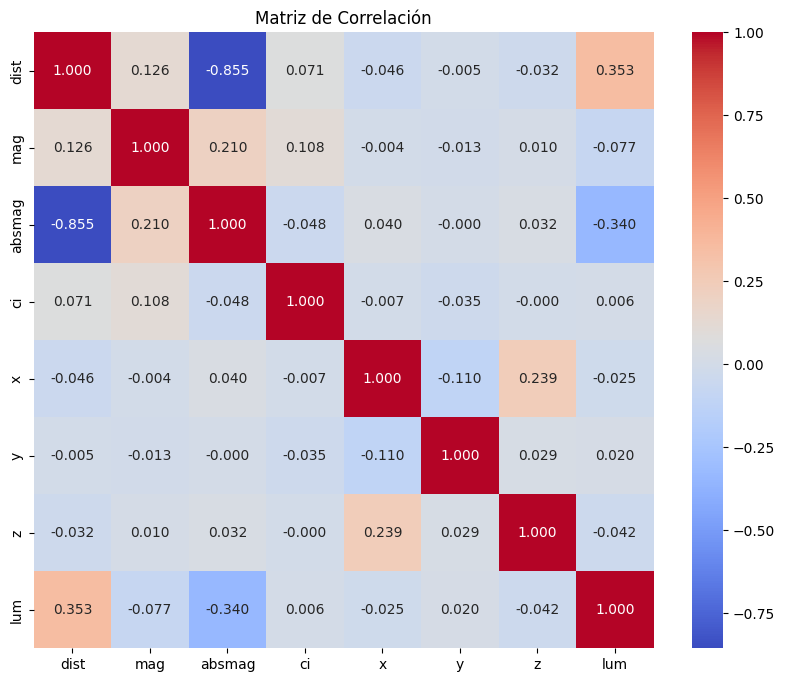

In [8]:
import seaborn as sns
matriz_correlacion = df_new.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".3f")
plt.title("Matriz de Correlación")
plt.show()

In [9]:
x = df_new.drop('dist', axis=1)
y = df_new['dist']

x_train, x_test, y_train, y_test = train_test_split(x, y, train_size=0.8, random_state=241)

pl = Pipeline([('pf',PolynomialFeatures(degree=2,include_bias=False)),
               ('lr',LinearRegression())])
pl.fit(x_train, y_train)

print("R^2 training:", pl.score(x_train, y_train))
print("R^2 test:", pl.score(x_test, y_test))

R^2 training: 0.9999578767845153
R^2 test: 0.9999551389905075


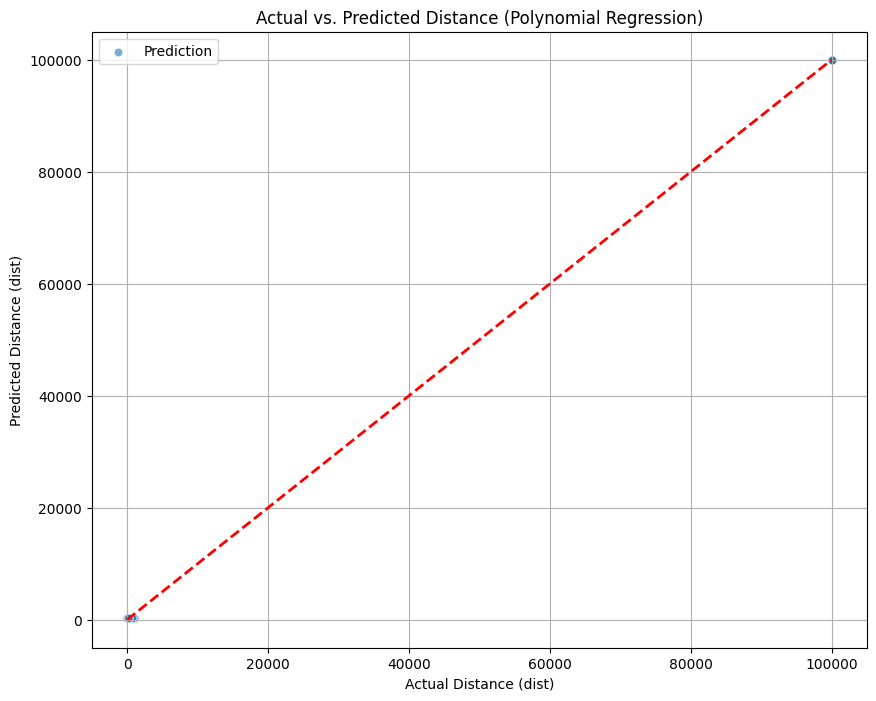

In [10]:
# Generate predictions on the test set
y_pred = pl.predict(x_test)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6,  label = 'Prediction')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Distance (dist)')
plt.ylabel('Predicted Distance (dist)')
plt.title('Actual vs. Predicted Distance (Polynomial Regression)')
plt.grid(True)
plt.show()

Quitamos todas las filas que tengan una distancia igual a 10000, ya que la base da datos redondea toda distancia mayor a esa a ese numero, tambien nos ayudara a hacer mas visible las siguientes graficas.

In [11]:
df_new1 = df_new[df_new['dist'] != 100000]
df_new1

,dist,mag,absmag,ci,x,y,z,lum
0,0.0000,-26.70,4.850,0.656,0.000005,0.000000,0.000000,1.000000
1,219.7802,9.10,2.390,0.482,219.740502,0.003449,4.177065,9.638290
2,47.9616,9.27,5.866,0.999,45.210918,0.003365,-16.008996,0.392283
3,442.4779,6.61,-1.619,-0.019,344.552785,0.030213,277.614965,386.901132
4,134.2282,8.06,2.421,0.370,82.835513,0.012476,-105.619540,9.366989
...,...,...,...,...,...,...,...,...
119608,18.5185,12.82,11.482,1.640,13.305832,-0.013199,-12.879810,0.002224
119610,7.8003,13.05,13.589,0.070,5.689088,0.054021,-5.336296,0.000319
119611,7.6336,10.96,11.260,1.690,5.131370,5.214404,-2.179650,0.002729
119612,15.8730,12.10,11.100,1.450,-10.462440,-10.555678,5.573837,0.003172


In [12]:
x1 = df_new1.drop('dist', axis=1)
y1 = df_new1['dist']

x_train1, x_test1, y_train1, y_test1 = train_test_split(x1, y1, train_size=0.8, random_state=241)

pl1 = Pipeline([('pf',PolynomialFeatures(degree=2,include_bias=False)),
               ('lr',LinearRegression())])
pl1.fit(x_train1, y_train1)

print("R^2 training:", pl1.score(x_train1, y_train1))
print("R^2 test:", pl1.score(x_test1, y_test1))

R^2 training: 0.994855228539606
R^2 test: 0.9951494130143705


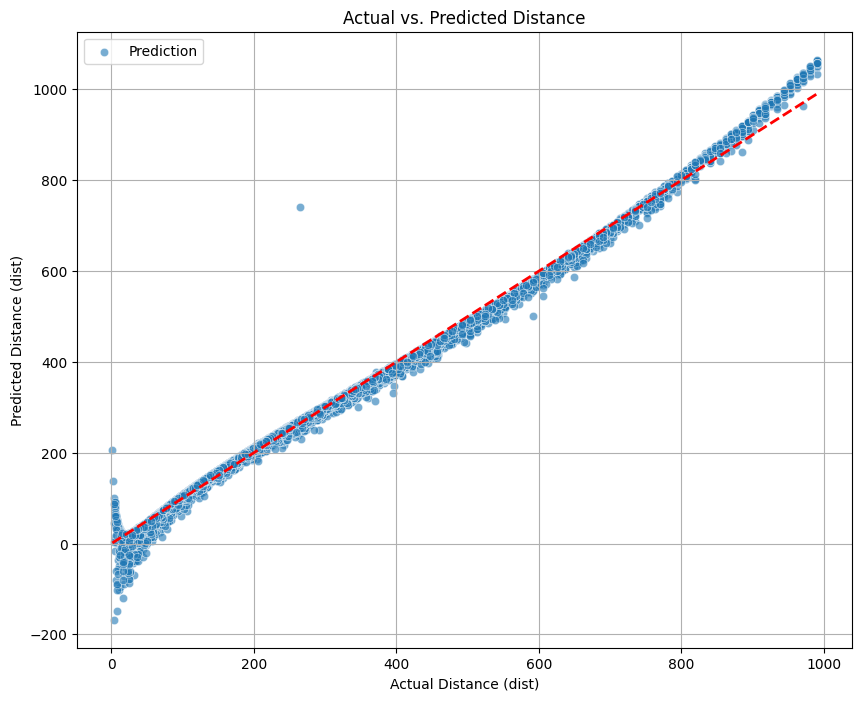

In [13]:
y_pred1 = pl1.predict(x_test1)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test1, y=y_pred1, alpha=0.6, label = 'Prediction')
plt.plot([y_test1.min(), y_test1.max()], [y_test1.min(), y_test1.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Distance (dist)')
plt.ylabel('Predicted Distance (dist)')
plt.title('Actual vs. Predicted Distance')
plt.grid(True)
plt.show()

In [14]:
x2 = df_new1.drop('ci', axis=1)
y2 = df_new1['ci']

x_train2, x_test2, y_train2, y_test2 = train_test_split(x2, y2, train_size=0.8, random_state=241)

pl2 = Pipeline([('pf',PolynomialFeatures(degree=2,include_bias=False)),
               ('lr',LinearRegression())])
pl2.fit(x_train2, y_train2)
#No matter the train size or the deegre, model was always low in score
print("R^2 training:", pl2.score(x_train2, y_train2))
print("R^2 test:", pl2.score(x_test2, y_test2))

R^2 training: 0.1499016651436592
R^2 test: 0.1478007522531305


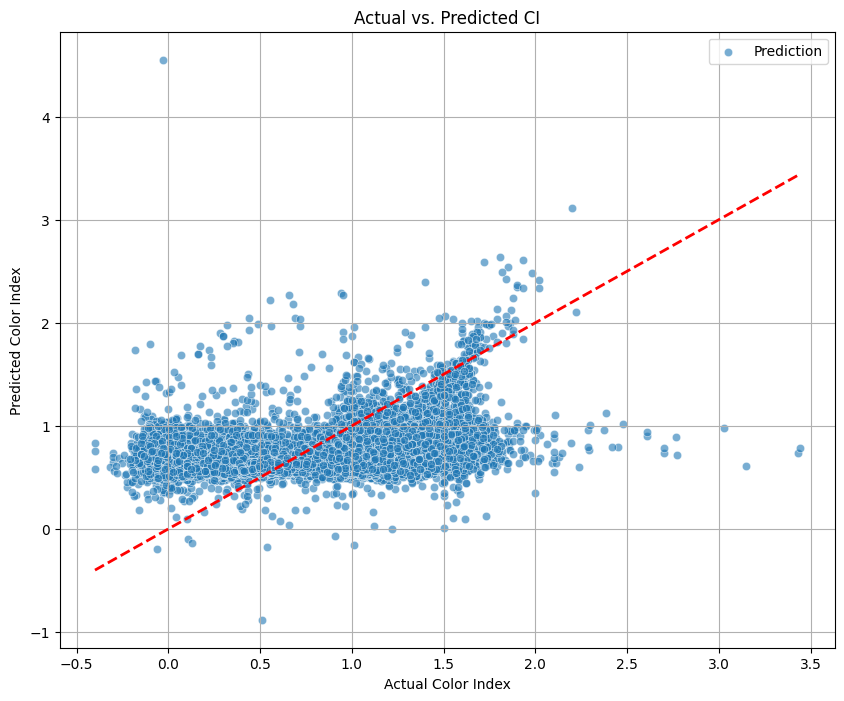

In [15]:
y_pred2 = pl2.predict(x_test2)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test2, y=y_pred2, alpha=0.6, label = 'Prediction')
plt.plot([y_test2.min(), y_test2.max()], [y_test2.min(), y_test2.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Color Index')
plt.ylabel('Predicted Color Index')
plt.title('Actual vs. Predicted CI')
plt.grid(True)
plt.show()

In [16]:
x3 = df_new1.drop('lum', axis=1)
y3 = df_new1['lum']

x_train3, x_test3, y_train3, y_test3 = train_test_split(x3, y3, train_size=0.8, random_state=241)

pl3 = Pipeline([('pf',PolynomialFeatures(degree=5,include_bias=False)),
               ('lr',LinearRegression())])
pl3.fit(x_train3, y_train3)
#Tried different degrees and train sizes, this is the best one
print("R^2 training:", pl3.score(x_train3, y_train3))
print("R^2 test:", pl3.score(x_test3, y_test3))

R^2 training: 0.9281092227666116
R^2 test: 0.8136388294992756


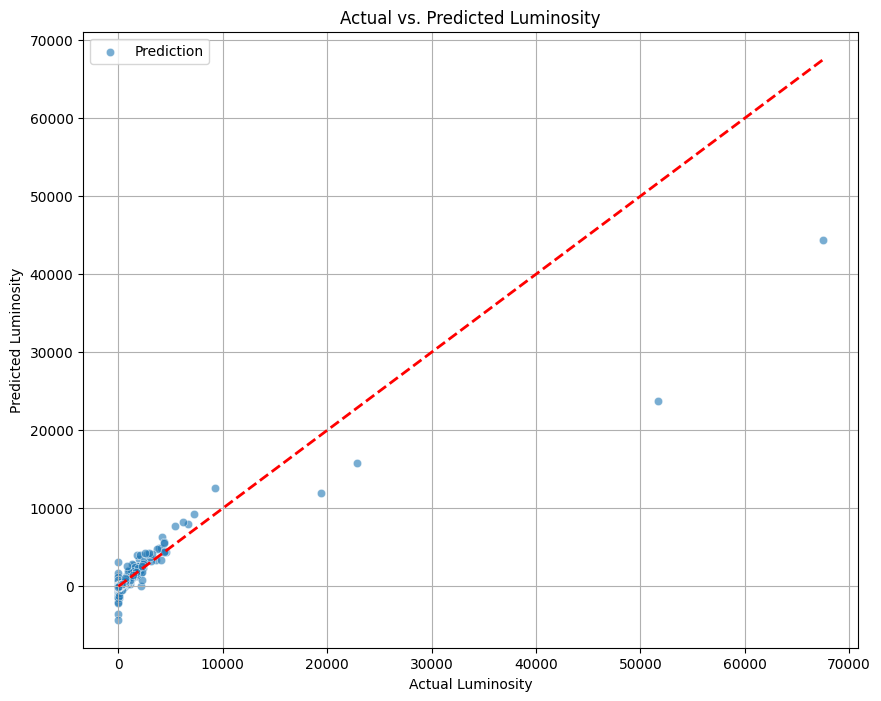

In [17]:
y_pred3 = pl3.predict(x_test3)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test3, y=y_pred3, alpha=0.6, label = 'Prediction')
plt.plot([y_test3.min(), y_test3.max()], [y_test3.min(), y_test3.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Luminosity')
plt.ylabel('Predicted Luminosity')
plt.title('Actual vs. Predicted Luminosity')
plt.grid(True)
plt.show()

In [18]:
x4 = df_new1.drop('mag', axis=1)
y4 = df_new1['mag']

x_train4, x_test4, y_train4, y_test4 = train_test_split(x4, y4, train_size=0.8, random_state=241)

pl4 = Pipeline([('pf',PolynomialFeatures(degree=2,include_bias=False)),
               ('lr',LinearRegression())])
pl4.fit(x_train4, y_train4)

print("R^2 training:", pl4.score(x_train4, y_train4))
print("R^2 test:", pl4.score(x_test4, y_test4))

R^2 training: 0.9231191056949565
R^2 test: 0.9248523993653164


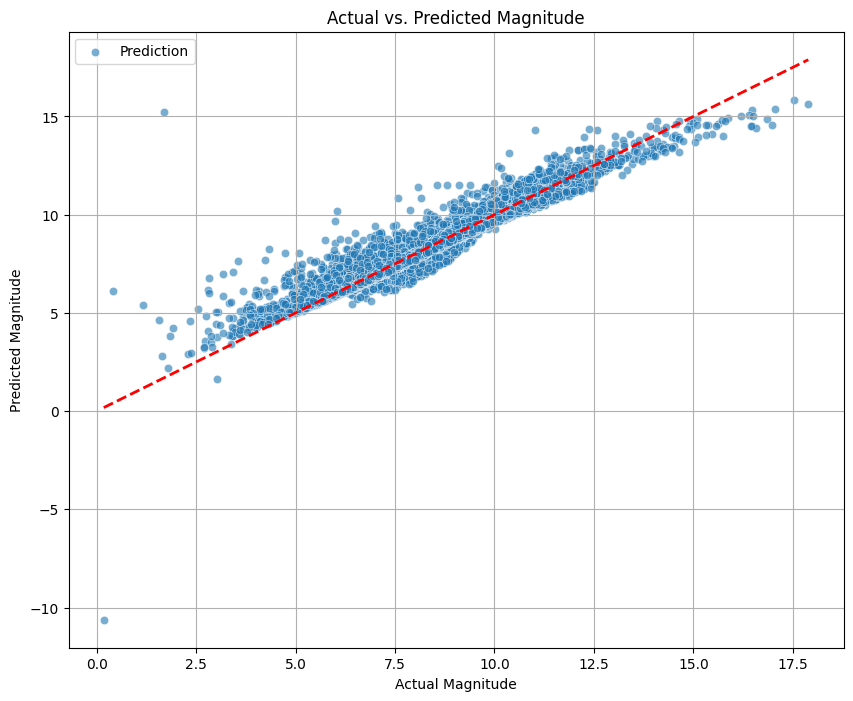

In [19]:
y_pred4 = pl4.predict(x_test4)

# Ensure y_test4 is numeric before calculating min/max and plotting
y_test4_numeric = pd.to_numeric(y_test4)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test4_numeric, y=y_pred4, alpha=0.6, label = 'Prediction')
plt.plot([y_test4_numeric.min(), y_test4_numeric.max()], [y_test4_numeric.min(), y_test4_numeric.max()], 'r--', lw=2, label = 'Perfect prediction')
plt.xlabel('Actual Magnitude')
plt.ylabel('Predicted Magnitude')
plt.title('Actual vs. Predicted Magnitude')
plt.grid(True)
plt.show()

La regresion polinomial tuvo, en su mayoria, unos resultados decentes, ahora veremos como desempena la regresion por Random Forest.

SVR R^2 training (distance): 0.9618864712749954
SVR R^2 test (distance): 0.9633600442316015


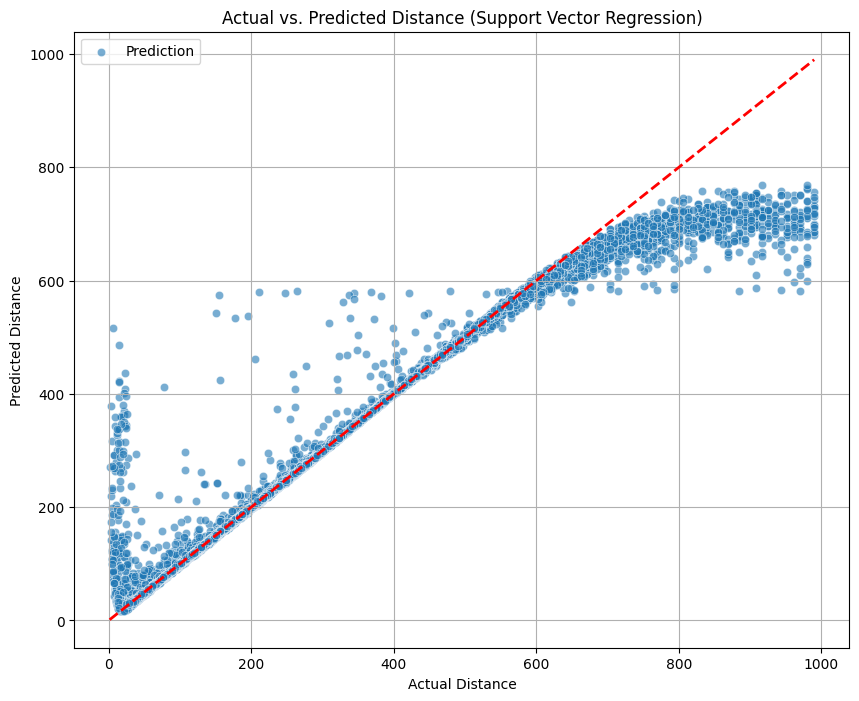

In [21]:
from sklearn.svm import SVR

svr_pl_dist = Pipeline([('scaler', StandardScaler()),('svr', SVR(kernel='rbf'))])
svr_pl_dist.fit(x_train1, y_train1)

print("SVR R^2 training (distance):", svr_pl_dist.score(x_train1, y_train1))
print("SVR R^2 test (distance):", svr_pl_dist.score(x_test1, y_test1))

y_pred_svr = svr_pl_dist.predict(x_test1)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test1, y=y_pred_svr, alpha=0.6, label='Prediction')
plt.plot([y_test1.min(), y_test1.max()], [y_test1.min(), y_test1.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Distance')
plt.ylabel('Predicted Distance')
plt.title('Actual vs. Predicted Distance (Support Vector Regression)')
plt.grid(True)
plt.show()

SVR R^2 training (CI): 0.22685603845922064
SVR R^2 test (CI): 0.20081690890630377


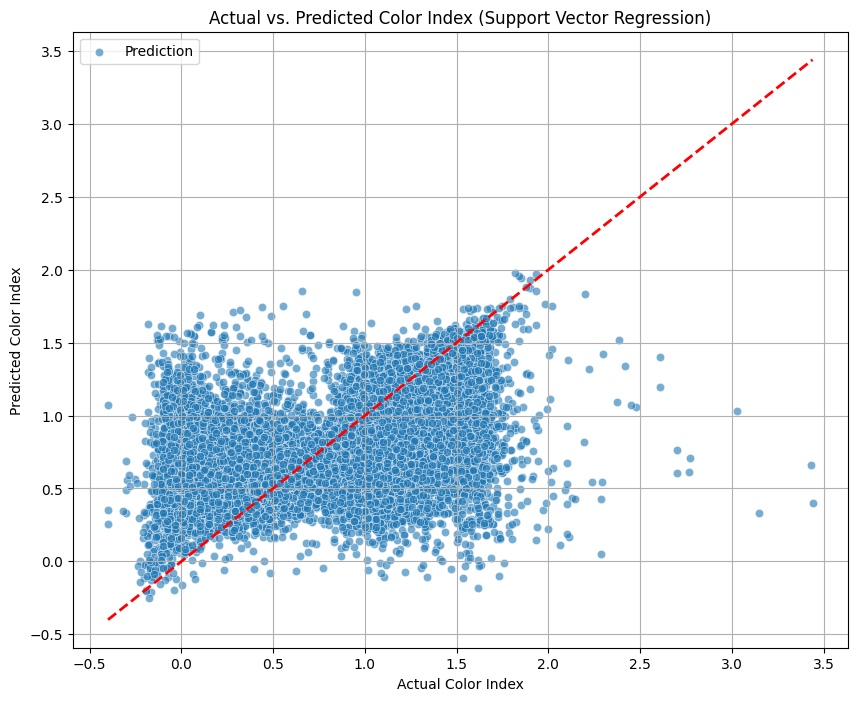

In [25]:
svr_pl_ci = Pipeline([('scaler', StandardScaler()),('svr', SVR(kernel='rbf'))])
svr_pl_ci.fit(x_train2, y_train2)

print("SVR R^2 training (CI):", svr_pl_ci.score(x_train2, y_train2))
print("SVR R^2 test (CI):", svr_pl_ci.score(x_test2, y_test2))

y_pred_svr_ci = svr_pl_ci.predict(x_test2)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test2, y=y_pred_svr_ci, alpha=0.6, label='Prediction')
plt.plot([y_test2.min(), y_test2.max()], [y_test2.min(), y_test2.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Color Index')
plt.ylabel('Predicted Color Index')
plt.title('Actual vs. Predicted Color Index (Support Vector Regression)')
plt.grid(True)
plt.show()

SVR R^2 training (Luminosity): 0.07075262872104982
SVR R^2 test (Luminosity): 0.03263973175511148


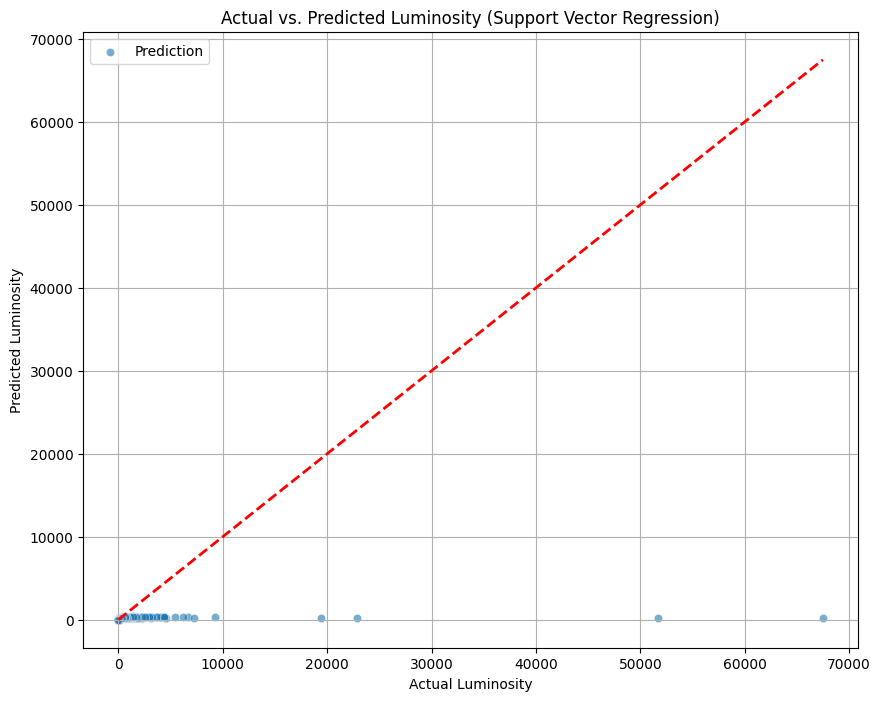

In [26]:
svr_pl_lum = Pipeline([('scaler', StandardScaler()),('svr', SVR(kernel='rbf'))])
svr_pl_lum.fit(x_train3, y_train3)

print("SVR R^2 training (Luminosity):", svr_pl_lum.score(x_train3, y_train3))
print("SVR R^2 test (Luminosity):", svr_pl_lum.score(x_test3, y_test3))

y_pred_svr_lum = svr_pl_lum.predict(x_test3)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test3, y=y_pred_svr_lum, alpha=0.6, label='Prediction')
plt.plot([y_test3.min(), y_test3.max()], [y_test3.min(), y_test3.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Luminosity')
plt.ylabel('Predicted Luminosity')
plt.title('Actual vs. Predicted Luminosity (Support Vector Regression)')
plt.grid(True)
plt.show()

SVR R^2 training (distance): 0.9807574780563493
SVR R^2 test (distance): 0.9846937659093667


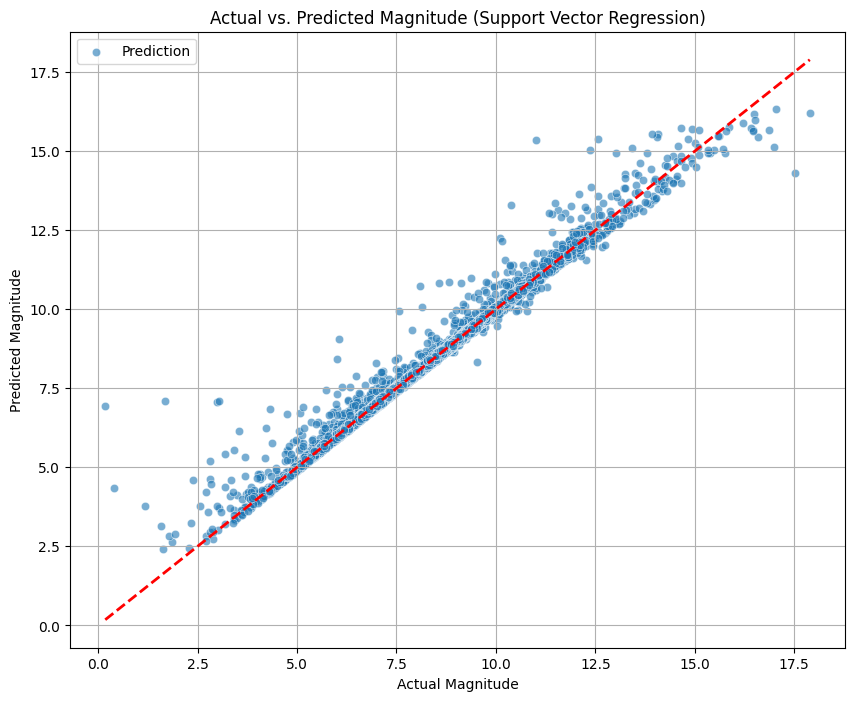

In [27]:
svr_pl_mag = Pipeline([('scaler', StandardScaler()),('svr', SVR(kernel='rbf'))])
svr_pl_mag.fit(x_train4, y_train4)

print("SVR R^2 training (distance):", svr_pl_mag.score(x_train4, y_train4))
print("SVR R^2 test (distance):", svr_pl_mag.score(x_test4, y_test4))

y_pred_svr_mag = svr_pl_mag.predict(x_test4)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test4, y=y_pred_svr_mag, alpha=0.6, label='Prediction')
plt.plot([y_test4.min(), y_test4.max()], [y_test4.min(), y_test4.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Magnitude')
plt.ylabel('Predicted Magnitude')
plt.title('Actual vs. Predicted Magnitude (Support Vector Regression)')
plt.grid(True)
plt.show()

RSV desempeno en algunas mejor y en otras peor, ahora veremos como desempena la regresion por Random Forest.

Random Forest R^2 training (distance): 0.9999486469585671
Random Forest R^2 test (distance): 0.9996964781027705


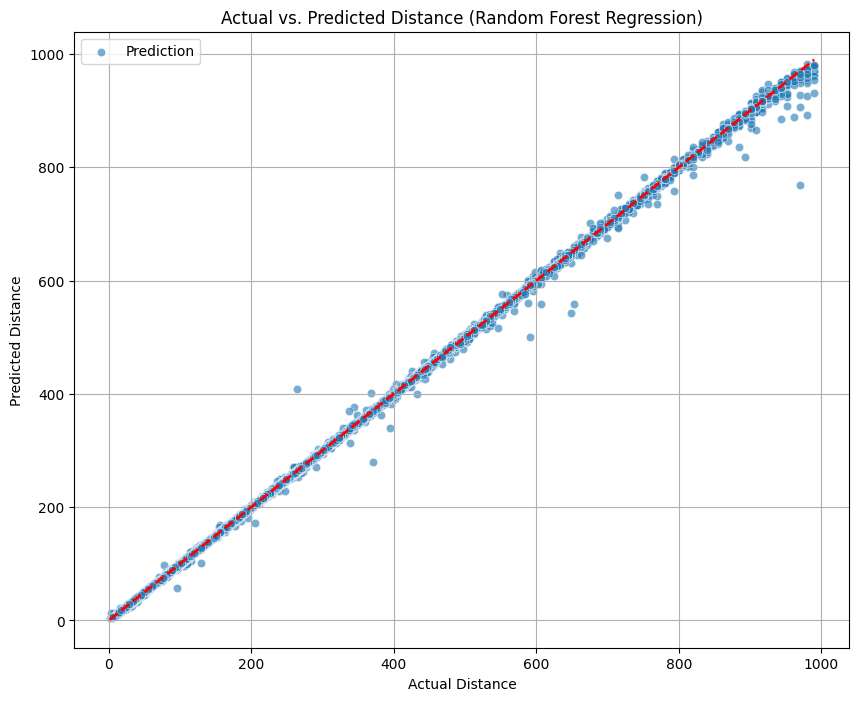

In [29]:
from sklearn.ensemble import RandomForestRegressor

rf_regressor_dist = RandomForestRegressor(n_estimators=100, random_state=241, n_jobs=-1)
rf_regressor_dist.fit(x_train1, y_train1)

y_pred_rf_dist = rf_regressor_dist.predict(x_test1)

print("Random Forest R^2 training (distance):", rf_regressor_dist.score(x_train1, y_train1))
print("Random Forest R^2 test (distance):", rf_regressor_dist.score(x_test1, y_test1))

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test1, y=y_pred_rf_dist, alpha=0.6, label='Prediction')
plt.plot([y_test1.min(), y_test1.max()], [y_test1.min(), y_test1.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Distance')
plt.ylabel('Predicted Distance')
plt.title('Actual vs. Predicted Distance (Random Forest Regression)')
plt.grid(True)
plt.show()

Random Forest R^2 training (ci): 0.8897607730850383
Random Forest R^2 test (ci): 0.2022572944780333


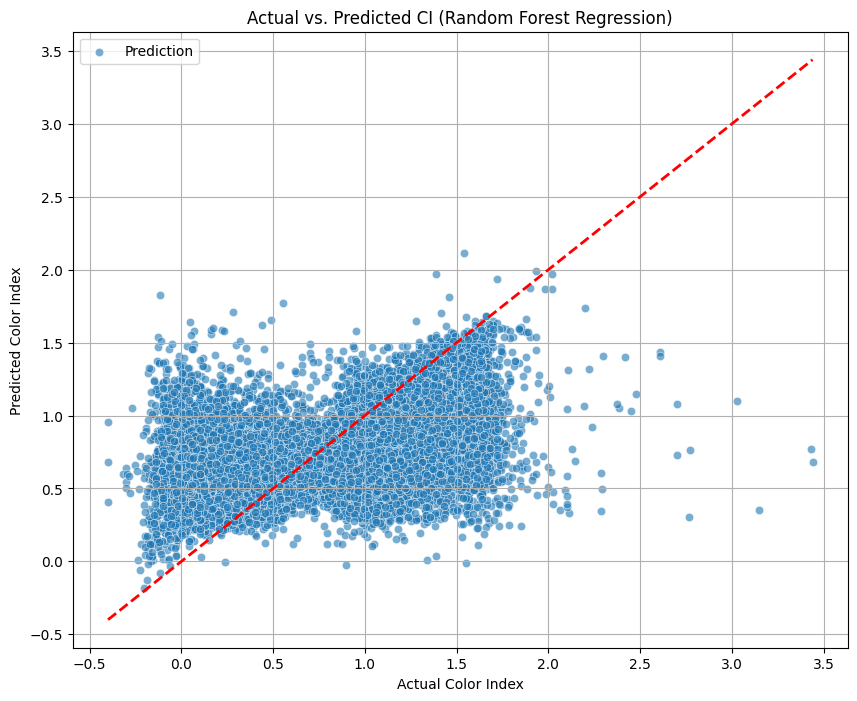

In [30]:
rf_regressor_ci = RandomForestRegressor(n_estimators=100, random_state=241, n_jobs=-1)
rf_regressor_ci.fit(x_train2, y_train2)

y_pred_rf_ci = rf_regressor_ci.predict(x_test2)

print("Random Forest R^2 training (ci):", rf_regressor_ci.score(x_train2, y_train2))
print("Random Forest R^2 test (ci):", rf_regressor_ci.score(x_test2, y_test2))

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test2, y=y_pred_rf_ci, alpha=0.6, label='Prediction')
plt.plot([y_test2.min(), y_test2.max()], [y_test2.min(), y_test2.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Color Index')
plt.ylabel('Predicted Color Index')
plt.title('Actual vs. Predicted CI (Random Forest Regression)')
plt.grid(True)
plt.show()

In [33]:
from sklearn.model_selection import RandomizedSearchCV

param_grid_rf = {
    'n_estimators': [100, 200, 300, 400, 500],
    'max_features': ['auto', 'sqrt', 'log2'],
    'max_depth' : [10, 20, 30, 40, 50, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False]
}

rf_random_dist = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=241, n_jobs=-1),
    param_distributions=param_grid_rf,
    n_iter=50,
    cv=3,
    verbose=2,
    random_state=241,
    n_jobs=-1
)

rf_random_dist.fit(x_train1, y_train1)

print("Best parameters for Random Forest (distance):", rf_random_dist.best_params_)
print("Best R^2 score for Random Forest (distance):", rf_random_dist.best_score_)

Fitting 3 folds for each of 50 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
39 fits failed out of a total of 150.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
22 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", l

Best parameters for Random Forest (distance): {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'bootstrap': False}
Best R^2 score for Random Forest (distance): 0.9975439493771142


Tuned Random Forest R^2 test (distance): 0.9984253817418379


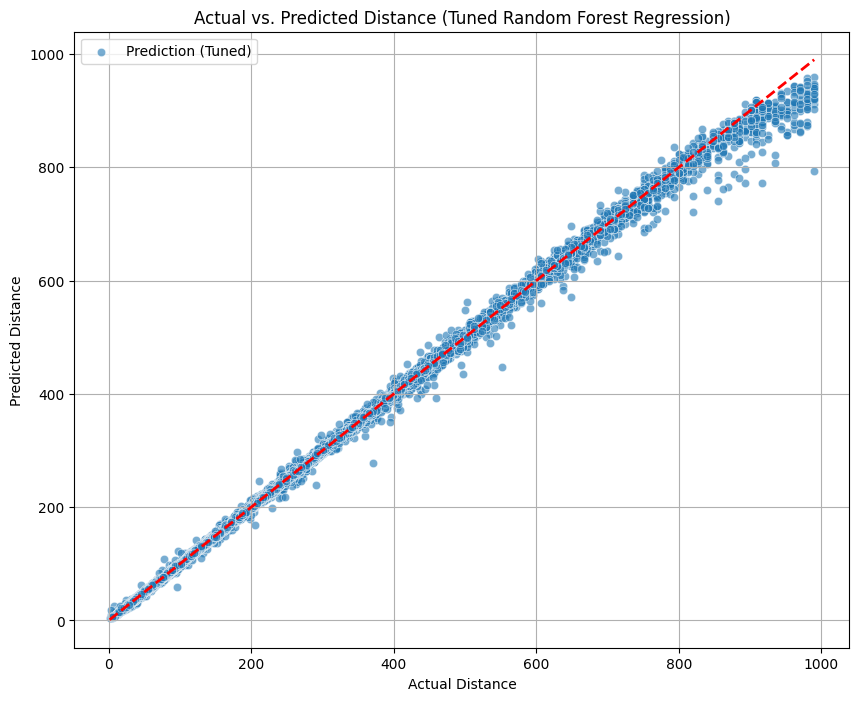

In [34]:
best_rf_dist = rf_random_dist.best_estimator_

y_pred_tuned_rf_dist = best_rf_dist.predict(x_test1)

print("Tuned Random Forest R^2 test (distance):", best_rf_dist.score(x_test1, y_test1))

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test1, y=y_pred_tuned_rf_dist, alpha=0.6, label='Prediction (Tuned)')
plt.plot([y_test1.min(), y_test1.max()], [y_test1.min(), y_test1.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Distance')
plt.ylabel('Predicted Distance')
plt.title('Actual vs. Predicted Distance (Tuned Random Forest Regression)')
plt.grid(True)
plt.show()

Buscaria los hiper parametros para los demas regresiones por Random Forest, pero debido al tiempo solo podre agregar una.

Random Forest R^2 training (ci): 0.996920853140026
Random Forest R^2 test (ci): 0.8896032646474148


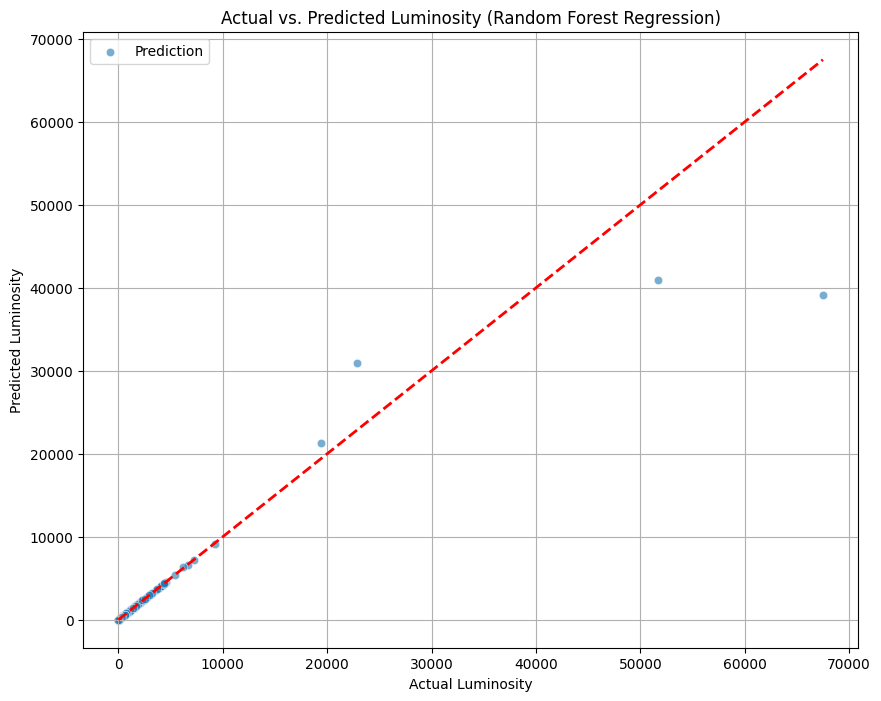

In [31]:
rf_regressor_lum = RandomForestRegressor(n_estimators=100, random_state=241, n_jobs=-1)
rf_regressor_lum.fit(x_train3, y_train3)

y_pred_rf_lum = rf_regressor_lum.predict(x_test3)

print("Random Forest R^2 training (ci):", rf_regressor_lum.score(x_train3, y_train3))
print("Random Forest R^2 test (ci):", rf_regressor_lum.score(x_test3, y_test3))

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test3, y=y_pred_rf_lum, alpha=0.6, label='Prediction')
plt.plot([y_test3.min(), y_test3.max()], [y_test3.min(), y_test3.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Luminosity')
plt.ylabel('Predicted Luminosity')
plt.title('Actual vs. Predicted Luminosity (Random Forest Regression)')
plt.grid(True)
plt.show()

Random Forest R^2 training (magnitude): 0.999346689123017
Random Forest R^2 test (magnitude): 0.999110414780334


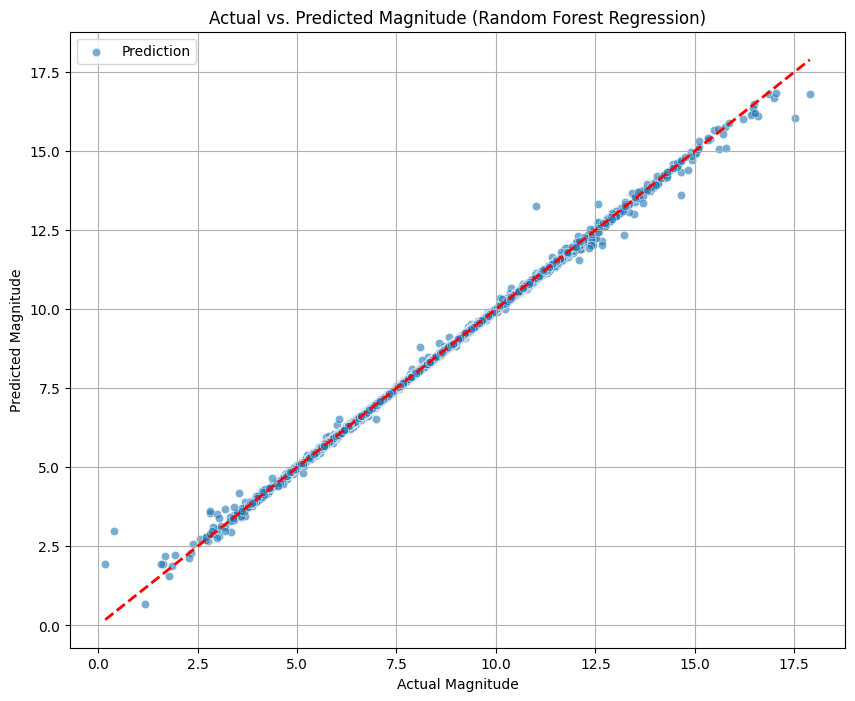

In [32]:
rf_regressor_mag = RandomForestRegressor(n_estimators=100, random_state=241, n_jobs=-1)
rf_regressor_mag.fit(x_train4, y_train4)

y_pred_rf_mag = rf_regressor_mag.predict(x_test4)

print("Random Forest R^2 training (magnitude):", rf_regressor_mag.score(x_train4, y_train4))
print("Random Forest R^2 test (magnitude):", rf_regressor_mag.score(x_test4, y_test4))

# Ensure y_test4 is numeric before calculating min/max and plotting
y_test4_numeric = pd.to_numeric(y_test4)

plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test4_numeric, y=y_pred_rf_mag, alpha=0.6, label='Prediction')
plt.plot([y_test4_numeric.min(), y_test4_numeric.max()], [y_test4_numeric.min(), y_test4_numeric.max()], 'r--', lw=2, label='Perfect prediction')
plt.xlabel('Actual Magnitude')
plt.ylabel('Predicted Magnitude')
plt.title('Actual vs. Predicted Magnitude (Random Forest Regression)')
plt.grid(True)
plt.show()

## Comparación de Resultados de Modelos

A continuación, se presenta una tabla de los resultados de los modelos de Regresión Polinomial, Random Forest y Support Vector Machine para cada variable objetivo:

| Variable Objetivo | Regresión Polinomial (Entrenamiento / Prueba) | Random Forest (Entrenamiento / Prueba) | SVM (Entrenamiento / Prueba) |
|-------------------|---------------------------------------------|----------------------------------------|------------------------------|
| `dist`            | 0.9950 / 0.9953                             | 0.9999 / 0.9997                        | 0.9619 / 0.9634              |
| `ci`              | 0.1578 / 0.1588                             | 0.8898 / 0.2023                        | 0.2269 / 0.2008              |
| `lum`             | 0.9281 / 0.8136                             | 0.9969 / 0.8896                        | 0.0708 / 0.0326              |
| `mag`             | 0.9231 / 0.9249                             | 0.9993 / 0.9991                        | 0.9808 / 0.9847              |

### Conclusión Rápida

En general, los modelos de **Random Forest** demostraron un rendimiento superior o comparable a la **Regresión Polinomial** y **SVM** para la mayoría de las variables objetivo. Para el `ci` (índice de color) y `lum` (luminosidad), los modelos de **Random Forest** mostraron una mejora significativa sobre la Regresión Polinomial y SVM, aunque su R^2 en el conjunto de prueba para `ci` sugiere que la predicción de esta variable podría ser más compleja o necesitar datos diferentes u otro método. Los modelos de **SVM** mostraron un rendimiento decente para la distancia y la magnitud, pero tuvieron dificultades con el índice de color y la luminosidad.